# OOI Pioneer NES (New England Shelf) Discrete Water Sample Data 

## OOI Water Sampling Data Archived at BCO-DMO

OOI Pioneer New England Shelf Array CTD and Water Sampling Data is published and archived through BCO-DMO (Biological and Chemical Oceanography Data Management Office). Full metadata for this dataset and access to the data files and metadata are available here: https://www.bco-dmo.org/dataset/966896.

As a part of the BCO-DMO curration process, files are also made available through BCO-DMO's ERDDAP server. The OOI Pioneer New England Shelf Array CTD and Water Sampling data file is available here: https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_966896_v1.html

## The Goals of this Notebook

This notebook reads data from OOI hosted on BCO-DMO’s ERDDAP server, applies basic quality control parameters, and plots Oxygen, Salinity, and Nitrate measurements from the Coastal Pioneer NES Array collected from 2013 to 2022. The goals of this notebook are to provide an overview of the discrete data available at this array, demonstrate simple quality control procedures, and illustrate examples of quick exploratory plots that can be generated.

The recommended citation for the dataset used in this notebook is: 

NSF Ocean Observatories Initiative (2025) OOI Coastal Pioneer New England Shelf Array CTD and Discrete Water Sampling Data from Mooring Overturning Cruises at the New England Continental Shelf from 2013-2022 (OOI Cruise Data Project). Biological and Chemical Oceanography Data Management Office (BCO-DMO). (Version 1) Version Date 2025-07-03 [if applicable, indicate subset used]. doi:10.26008/1912/bco-dmo.966896.1 [access date]

## Set Up (if you clone and run this notebook locally)

The GitHub repository containing this notebook includes information about dependencies (and versions) in .yml files.

In [72]:
# Import modules
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from matplotlib.dates import AutoDateLocator, AutoDateFormatter
import cmocean.cm as cmo # colormaps for commonly-used oceanographic variables
import seaborn as sns

In [73]:
# print(mpl.__version__) # if plot cell results in error check version of matplotlib

## Load OOI data from BCO-DMO's ERDDAP into workspace

To access the data in comma separated variable (CSV) format through ERDDAP, you can either:

1. Access the File through the URL at BCO-DMO (Biological and Chemical Oceanography Data Management Office) ERDDAP > Files (this is the method used within this notebook).
2. Generate a URL using the ERDDAP Data Access Form
    * If using the ERDDAP Data Access Form, file type .csvp provides a single header row.
    * If using the ERDDAP Data Access Form, you can subset (e.g., select variables of interest) prior to loading the data.

In [74]:
# Point to the BCO-DMO ERDDAP dataset URL
url = "https://erddap.bco-dmo.org/erddap/files/bcodmo_dataset_966896_v1/966896_v1_ooi_pioneer_nes_ctd_and_water_sampling_data.csv"

# Read the datase from the URL into a pandas dataframe
df = pd.read_csv(url)

# Check the first few rows to ensure the dataset has been loaded and generally looks as expected
df.head()


,Cruise,Station,Target_Asset,Start_Latitude,Start_Longitude,Start_Time,Cast,Cast_Flag,Bottom_Depth_at_Start_Position,CTD_File,...,Discrete_pH_Replicate_Flag,Calculated_Alkalinity,Calculated_DIC,Calculated_pCO2,Calculated_pH,Calculated_CO2aq,Calculated_Bicarb,Calculated_CO3,Calculated_Omega_C,Calculated_Omega_A
0,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
# Optional exploration step: display the number of rows present in the read-in data
print(df.shape[0])

3755


In [76]:
# Convert the CTD Bottle Closure Time to a datetime data type
df["CTD_Bottle_Closure_Time"] = pd.to_datetime(df["CTD_Bottle_Closure_Time"], utc=True, errors="coerce")
df.dtypes["CTD_Bottle_Closure_Time"]

datetime64[ns, UTC]

## Apply QC Flags

Apply QC flags
For functions to interpret OOI discrete sample CTD flags to QARTOD QC-flags please see bottles.py file in https://github.com/oceanobservatories/ooi-data-explorations. For your convience, the module has also been included in this repository.

In [77]:
# display unique Discrete Sample flags
# df.Discrete_Oxygen_Flag.unique() # display unique one column
pd.unique(df[["Discrete_Oxygen_Flag", "Discrete_Salinity_Flag", "Discrete_Nutrients_Flag"]].values.ravel('K')) # display unique multiple columns

#numeric_cols = [
#    "Discrete_Oxygen",
#    "Discrete_Salinity",
#    "Discrete_Nitrate",
#    "CTD_Depth"
#]

#for col in numeric_cols:
#    df[col] = pd.to_numeric(df[col], errors="coerce")


array(['*0000000000000100', nan, '*0000000000001000', '*0000000000001001',
       '*BD22:BD1170000000000000100', '*0000000000010001',
       '*0000000000000001', '*0000000000000101'], dtype=object)

In [78]:
# Assign "Acceptable" flags to QARTOD 
## Note: there is an issue with 1 flag, which excludes a good data value '*BD22:BD1170000000000000100' (this affects just one row AR18B cast 012 niskin 8)

flag1 = "*0000000000000100" # Good 1 in Bit Position 2 (i.e., 3rd from right)
flag2 = "*0000000000000101" # this example had 2 unique "Acceptable" flags

df.loc[df.Discrete_Oxygen_Flag == flag1, 'Discrete_Oxygen_Flag'] = 1       # assign QARTOD Good
df.loc[df.Discrete_Oxygen_Flag == flag2, 'Discrete_Oxygen_Flag'] = 1       # assign QARTOD Good
df.loc[df.Discrete_Salinity_Flag == flag1, 'Discrete_Salinity_Flag'] = 1   # assign QARTOD Good
df.loc[df.Discrete_Salinity_Flag == flag2, 'Discrete_Salinity_Flag'] = 1   # assign QARTOD Good
df.loc[df.Discrete_Nutrients_Flag == flag1, 'Discrete_Nutrients_Flag'] = 1 # assign QARTOD Good
df.loc[df.Discrete_Nutrients_Flag == flag2, 'Discrete_Nutrients_Flag'] = 1 # assign QARTOD Good

# Display unique Discrete Sample flags
pd.unique(df[["Discrete_Oxygen_Flag", "Discrete_Salinity_Flag", "Discrete_Nutrients_Flag"]].values.ravel('K')) # display unique multiple columns


array([1, nan, '*0000000000001000', '*0000000000001001',
       '*BD22:BD1170000000000000100', '*0000000000010001',
       '*0000000000000001'], dtype=object)

In [79]:
# Subset Data Frame to Discrete Samples with Acceptable flags
df_qc = df.query("Discrete_Oxygen_Flag==1 | Discrete_Salinity_Flag==1 | Discrete_Nutrients_Flag==1")
print(f"This subset of Discrete Samples with Acceptable flags reduced the total data points from {len(df)} to {len(df_qc)}")

This subset of Discrete Samples with Acceptable flags reduced the total data points from 3755 to 1875


## Configure Plot Settings
Set themes, styles, and global parameters for matplotlib figures. 

In [80]:
# For indexing multi-panel plots with matplotlib 
flag_oxy = df_qc["Discrete_Oxygen_Flag"]==1
flag_sal = df_qc["Discrete_Salinity_Flag"]==1
flag_ntr = df_qc["Discrete_Nutrients_Flag"]==1

In [81]:
# Assign colormaps from cmocean package
cmap_oxy = cmo.deep_r
cmap_salt = cmo.haline
cmap_nitr = cmo.matter
#cmap_chl = cmo.algae
cmap_time = cmo.tempo_r

In [82]:
# Configure time values for matplotlib plots
time = df_qc["CTD_Bottle_Closure_Time"].dt.tz_convert(None)

# Create a matplotlib-friendly numeric time array
mpl_time = mpl.dates.date2num(time)

# Create normalizer for colorbar representing the full date range
normalizer = Normalize(mpl_time[0], mpl_time[-1])

# Create tick locator for using time as the color scale
locator = AutoDateLocator()

## Plot Quality Controlled Data


### Viewing oxygen, salinity and nitrate measurements from discrete bottle profiles per year

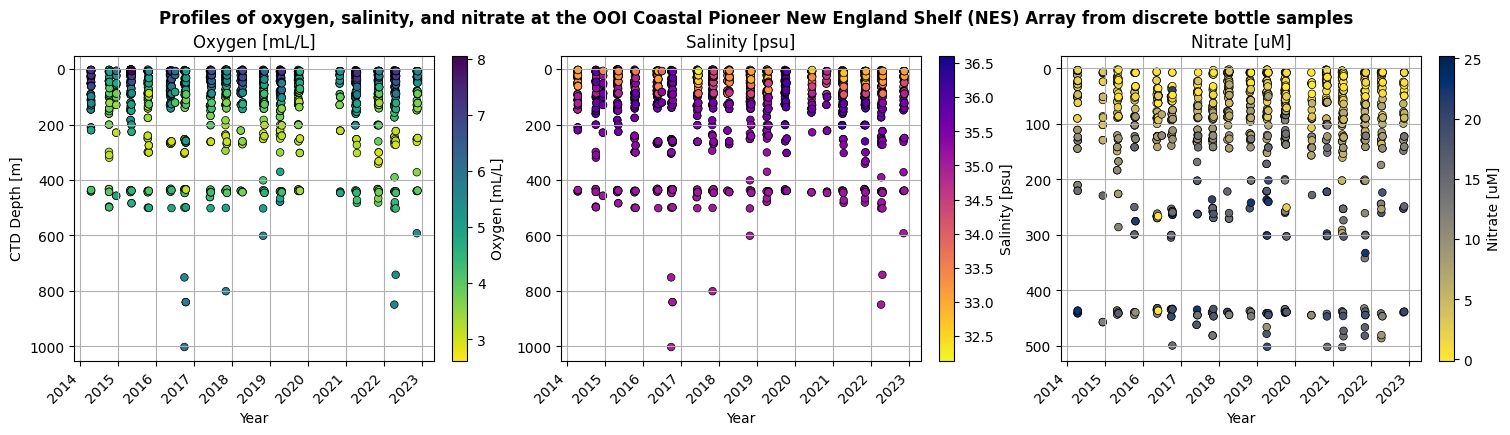

In [83]:
# Create figure and subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=False, constrained_layout=True)

# Discrete Oxygen
sc0 = axs[0].scatter(x=mpl_time[flag_oxy],
                     y=df_qc["CTD_Depth"][flag_oxy],
                     s=30, c=df_qc["Discrete_Oxygen"][flag_oxy],
                     cmap="viridis_r", edgecolors="k", linewidths=0.5)
axs[0].invert_yaxis()
axs[0].grid()
axs[0].set_xlabel("Year")
axs[0].set_ylabel("CTD Depth [m]")
axs[0].set_title("Oxygen [mL/L]")

# Discrete Salinity
sc1 = axs[1].scatter(x=mpl_time[flag_sal],
                     y=df_qc["CTD_Depth"][flag_sal],
                     s=30, c=df_qc["Discrete_Salinity"][flag_sal],
                     cmap="plasma_r", edgecolors="k", linewidths=0.5)
axs[1].invert_yaxis()
axs[1].grid()
axs[1].set_xlabel("Year")
axs[1].set_title("Salinity [psu]")

# Discrete Nitrate
sc2 = axs[2].scatter(x=mpl_time[flag_ntr],
                     y=df_qc["CTD_Depth"][flag_ntr],
                     s=30, c=df_qc["Discrete_Nitrate"][flag_ntr],
                     cmap="cividis_r", edgecolors="k", linewidths=0.5)
axs[2].invert_yaxis()
axs[2].grid()
axs[2].set_xlabel("Year")
axs[2].set_title("Nitrate [uM]")

# Add colorbars
fig.colorbar(sc0, ax=axs[0], orientation="vertical", label="Oxygen [mL/L]")
fig.colorbar(sc1, ax=axs[1], orientation="vertical", label="Salinity [psu]")
fig.colorbar(sc2, ax=axs[2], orientation="vertical", label="Nitrate [uM]")

# Format dates
locator = AutoDateLocator()
formatter = AutoDateFormatter(locator)
for ax in axs:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

# Or automatically adjust
fig.autofmt_xdate()
fig.suptitle("Profiles of oxygen, salinity, and nitrate at the OOI Coastal Pioneer New England Shelf (NES) Array from discrete bottle samples", fontsize=12, fontweight="bold", y=1.05)
plt.show()
plt.show()

**Figure 1.** (Above) Profiles of oxygen, salinity, and nitrate at the OOI Coastal Pioneer New England Shelf (NES) Array from discrete bottle samples.

## Overviewing Temporal Variability of Oxygen, Salinity and Nitrate from Discrete Bottle Samples as Overlayed Profiles


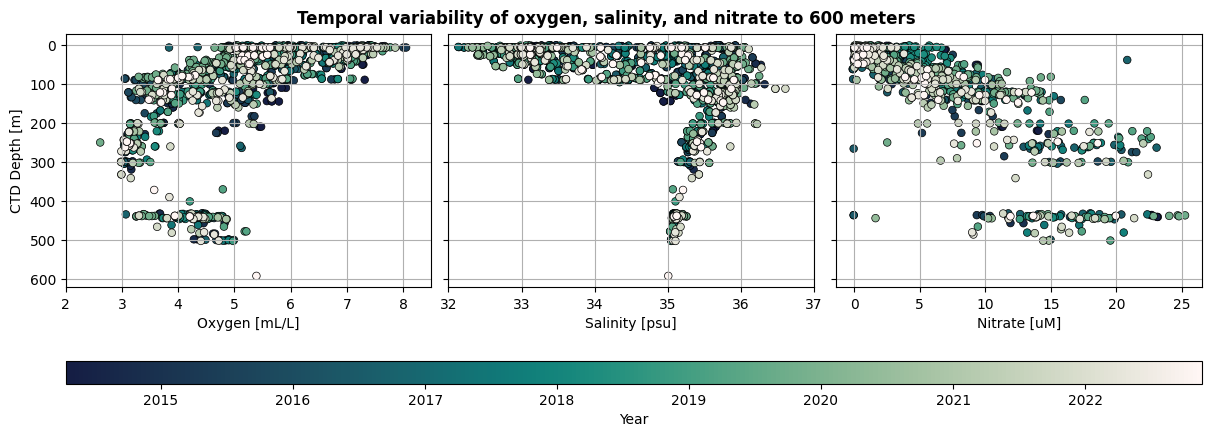

In [84]:
# Base slice once
base = df_qc.loc[df_qc["CTD_Depth"] <= 600].copy()

# Color series aligned to base
cseries = pd.Series(mpl_time, index=df_qc.index).reindex(base.index)

# Reindex flags to base (avoid length mismatch)
flag_oxy_b = pd.Series(flag_oxy, index=df_qc.index).reindex(base.index).fillna(False)
flag_sal_b = pd.Series(flag_sal, index=df_qc.index).reindex(base.index).fillna(False)
flag_ntr_b = pd.Series(flag_ntr, index=df_qc.index).reindex(base.index).fillna(False)

panels = [
    ("Discrete_Oxygen", flag_oxy_b, "Oxygen [mL/L]", (2, 8.5)),
    ("Discrete_Salinity", flag_sal_b, "Salinity [psu]", (32, 37)),
    ("Discrete_Nitrate", flag_ntr_b, "Nitrate [uM]", None),
]

fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True, constrained_layout=True)

for ax, (col, m, xlabel, xlim) in zip(axs, panels):
    # select rows once; dropna so x,y,c share identical index
    data = base.loc[m, [col, "CTD_Depth"]].dropna()
    ax.scatter(
        data[col],
        data["CTD_Depth"],
        s=30,
        c=cseries.loc[data.index],
        cmap=cmap_time, norm=normalizer,
        edgecolors="k", linewidths=0.5,
    )
    ax.invert_yaxis()
    ax.grid()
    ax.set_xlabel(xlabel)
    if xlim: ax.set_xlim(xlim)

axs[0].set_ylabel("CTD Depth [m]")

locator = AutoDateLocator()
cbar = fig.colorbar(cm.ScalarMappable(norm=normalizer, cmap=cmap_time),
                    ax=axs, orientation="horizontal", aspect=50, pad=0.1, ticks=locator)
cbar.ax.xaxis.set_major_formatter(AutoDateFormatter(locator))
cbar.set_label("Year")
fig.suptitle("Temporal variability of oxygen, salinity, and nitrate to 600 meters", fontsize=12, fontweight="bold", y=1.05)
plt.show()

**Figure 2.** (Above) Temporal variability of oxygen, salinity, and nitrate from discrete bottle samples over 9 years depicted as overlaid profiles.

## Comparing Measured Discrete vs CTD Values per Target Asset for a Single Year

In [85]:
def plot_ctd_vs_discrete_profiles(df, year=2023, variable="Salinity", target_assets=None, depth_col="CTD_Depth", units=None):
    """
    Plots side-by-side CTD and Discrete variable profiles by Target_Asset for a given year.

    - Uses colorblind-friendly warm colors for CTD and cool colors for Discrete.
    - Skips empty plots.
    - Preserves exact column names in legend.

    Parameters:
    - df: pandas DataFrame
    - year: int
    - variable: str (e.g., "Oxygen", "pH")
    - target_assets: list of strings (optional)
    - depth_col: str (default = "CTD_Depth")
    """
    df = df.copy()
    df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")

    # Select relevant columns
    ctd_cols = [col for col in df.columns if col.startswith(f"CTD_{variable}") and "Flag" not in col and "Replicate" not in col and "Saturation" not in col]
    disc_cols = [col for col in df.columns if col.startswith(f"Discrete_{variable}") and "Flag" not in col and "Replicate" not in col and "Saturation" not in col]

    if not ctd_cols and not disc_cols:
        print(f"❌ No matching CTD or Discrete columns found for variable '{variable}'")
        return

    df_filtered = df[
        (df["Start_Time"].dt.year == year) &
        (df[depth_col].notna()) &
        (df["Target_Asset"].notna())
    ]

    available_assets = sorted(df_filtered["Target_Asset"].dropna().unique())
    if target_assets is None:
        assets_to_plot = available_assets
    else:
        assets_to_plot = [a for a in target_assets if a in available_assets]

    if not assets_to_plot:
        print(f"❌ No valid data for {year} and selected Target_Assets.")
        return

    # Filter only assets with data
    plot_data = []
    for asset in assets_to_plot:
        subset = df_filtered[df_filtered["Target_Asset"] == asset]
        has_data = any(subset[col].notna().any() for col in (ctd_cols + disc_cols))
        if has_data:
            plot_data.append((asset, subset))
        else:
            print(f"⚠️ No data to plot for Target_Asset '{asset}' and variable '{variable}' in {year}.")

    if not plot_data:
        print(f"❌ No data found to plot for variable '{variable}' in {year}.")
        return

    # Color palettes (colorblind-friendly)
    warm_colors = ["#E66100", "#F6C141", "#B62000", "#A95AA1", "#E17C05", "#FFB000"]  # CTD
    cool_colors = ["#5B9BD5", "#0072B2", "#56B4E9", "#117733", "#66C2A5", "#009E73"]  # Discrete

    ctd_colors = {col: warm_colors[i % len(warm_colors)] for i, col in enumerate(ctd_cols)}
    disc_colors = {col: cool_colors[i % len(cool_colors)] for i, col in enumerate(disc_cols)}

    # Plot
    fig, axs = plt.subplots(1, len(plot_data), figsize=(4 * len(plot_data), 6), sharey=True, constrained_layout=True)
    if len(plot_data) == 1:
        axs = [axs]

    for i, (asset, subset) in enumerate(plot_data):
        ax = axs[i]

        for col in ctd_cols:
            col_data = subset.dropna(subset=[col])
            if not col_data.empty:
                ax.plot(col_data[col], col_data[depth_col],
                        label=col, color=ctd_colors[col],
                        marker='o', linestyle='-', linewidth=1.2, alpha=0.85)

        for col in disc_cols:
            col_data = subset.dropna(subset=[col])
            if not col_data.empty:
                ax.plot(col_data[col], col_data[depth_col],
                        label=col, color=disc_colors[col],
                        marker='s', linestyle='--', linewidth=1.2, alpha=0.85)

        ax.invert_yaxis()
        ax.set_title(asset)
        ax.set_xlabel(f"{variable} {units}")
        if i == 0:
            ax.set_ylabel("CTD Depth [m]")
        ax.grid(True)
        ax.legend(fontsize="small")

    plt.suptitle(f"CTD vs Discrete {variable} Profiles by Target Asset during {year}", fontsize=12, fontweight="bold")
    plt.show()

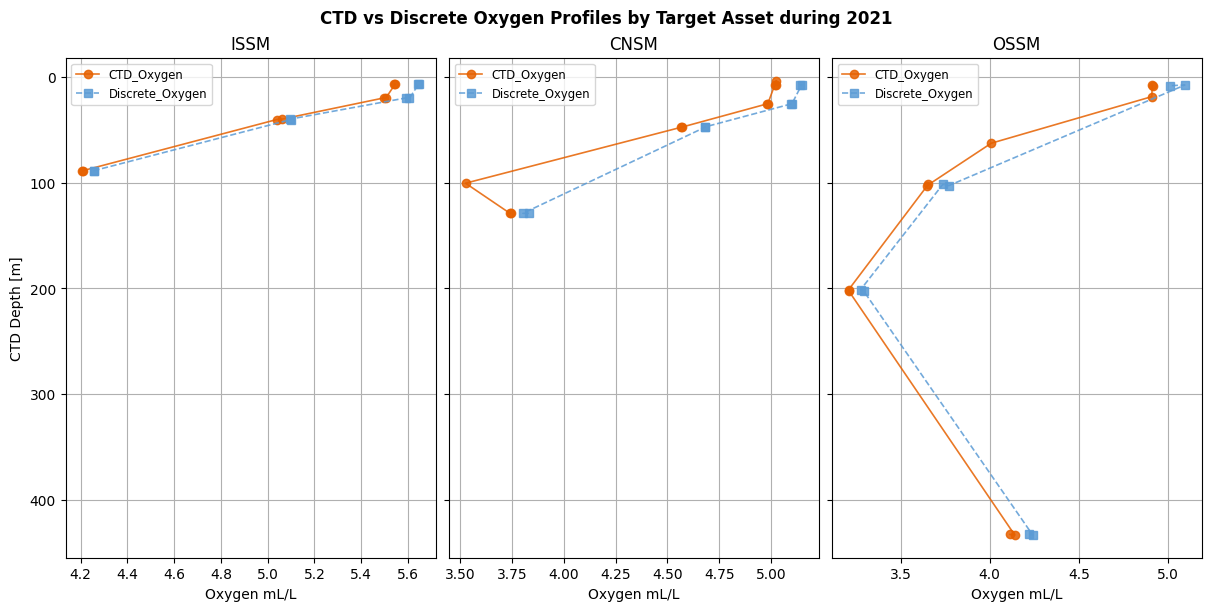

In [86]:
plot_ctd_vs_discrete_profiles(df_qc, year=2021, variable="Oxygen", units="mL/L", target_assets=["ISSM", "CNSM", "OSSM"])

**Figure 3.** (Above) Profiles of discrete sample oxygen and CTD rosette-mounted oxygen observations at the time of bottle closure per Pioneer NES Site; Inshore Surface Mooring (ISSM), Central Surface Mooring (CNSM) and Offshore Surface Mooring (OSSM).

## Visualizing Seasonal Temperature Profiles by Cruise and Depth (Hovmöller Plot)

This section generates a heatmap in which each column represents a cruise, the Y-axis shows depth (increasing downward), and color indicates the mean temperature within 10-meter bins. Pioneer NES cruises typically occurred twice per year—once in spring and once in fall, enabling seasonal comparisons of measured parameters.

In [87]:
def hovmoller_depth_cruise(df, var="CTD_Temperature_1", depth_col="CTD_Depth",
                            bin_size=10, cruise_col="Cruise", season_labels=False):
    """
    Hovmöller-style heatmap to visualize how a water column variable changes with depth over a sequence of cruises.

    WHY THIS IS USEFUL:
    - Shows how vertical structure of a variable (e.g., oxygen, pH) changes over time or across cruises
    - Great for datasets with seasonal cruises (like spring/fall sampling)
    - Highlights interannual or seasonal patterns in the upper water column

    PARAMETERS:
    ----------
    df : pandas DataFrame
        Your dataset including a datetime column (Start_Time), depth, cruise name, and the variable to plot
    var : str
        The name of the variable to visualize (e.g., "Discrete_Oxygen")
    depth_col : str
        The column containing CTD or bottle depth values
    bin_size : int
        Vertical resolution in meters (e.g., bin all depths in 10 m steps)
    cruise_col : str
        Column name that holds cruise ID (e.g., "Cruise")
    season_labels : bool
        If True, uses "Spring/Fall Year" labels instead of raw cruise names

    OUTPUT:
    ------
    A heatmap with:
    - Y-axis: Depth (deeper is lower)
    - X-axis: Cruise or season-year
    - Color: Mean value of the variable in each cruise–depth bin (darker = higher)
    """
    # Copy to avoid modifying original dataframe
    df = df.copy()

    # Convert Start_Time to datetime to allow time-based filtering
    df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")

    # Keep only necessary columns and drop missing data
    df = df[[var, cruise_col, depth_col, "Start_Time"]].dropna()
    
    # Filter the dataset to only show values up to 150 meters in depth
    df = df[df["CTD_Depth"] <= 150]

    if df.empty:
        print(f"❌ No data for {var}")
        return

    # Optional: Replace cruise names with "Spring 2024", "Fall 2024", etc.
    if season_labels:
        df["Season"] = df["Start_Time"].dt.month.map(lambda m: "Spring" if m < 7 else "Fall")
        df["Cruise_Label"] = df["Start_Time"].dt.year.astype(str) + " " + df["Season"]
    else:
        df["Cruise_Label"] = df[cruise_col]

    # Bin depth into regular intervals (e.g., every 10 meters)
    df["Depth_bin"] = (df[depth_col] // bin_size * bin_size).astype(int)

    # Create a pivot table: rows = depth bins, columns = cruise labels, values = mean of selected variable
    pivot = df.groupby(["Depth_bin", "Cruise_Label"])[var].mean().unstack()

    # If using season-year labels, sort columns chronologically
    if season_labels:
        cruise_order = df.groupby("Cruise_Label")["Start_Time"].min().sort_values().index
        pivot = pivot[cruise_order]

    # Plot the heatmap
    fig, ax = plt.subplots(figsize=(1.2 * len(pivot.columns), 6))
    sns.heatmap(
    pivot.sort_index(ascending=False),
    cmap="cividis_r",  # ⬅️ reversed colormap so higher = darker
    cbar_kws={'label': f"{var} (mean)"},
    ax=ax
)

    # Titles and labels
    ax.set_title(f"{var} by Depth and Cruise Season per year", fontsize=18, fontweight="bold")
    ax.set_xlabel("Cruise" if not season_labels else "Season & Year")
    ax.set_ylabel("Depth [m]")

    # Make deeper depths appear lower on Y-axis
    ax.invert_yaxis()

    # Improve layout
    plt.tight_layout()
    #plt.suptitle(f"{var} by Depth and Cruise Season per Year", fontsize=12, fontweight="bold")
    plt.show()

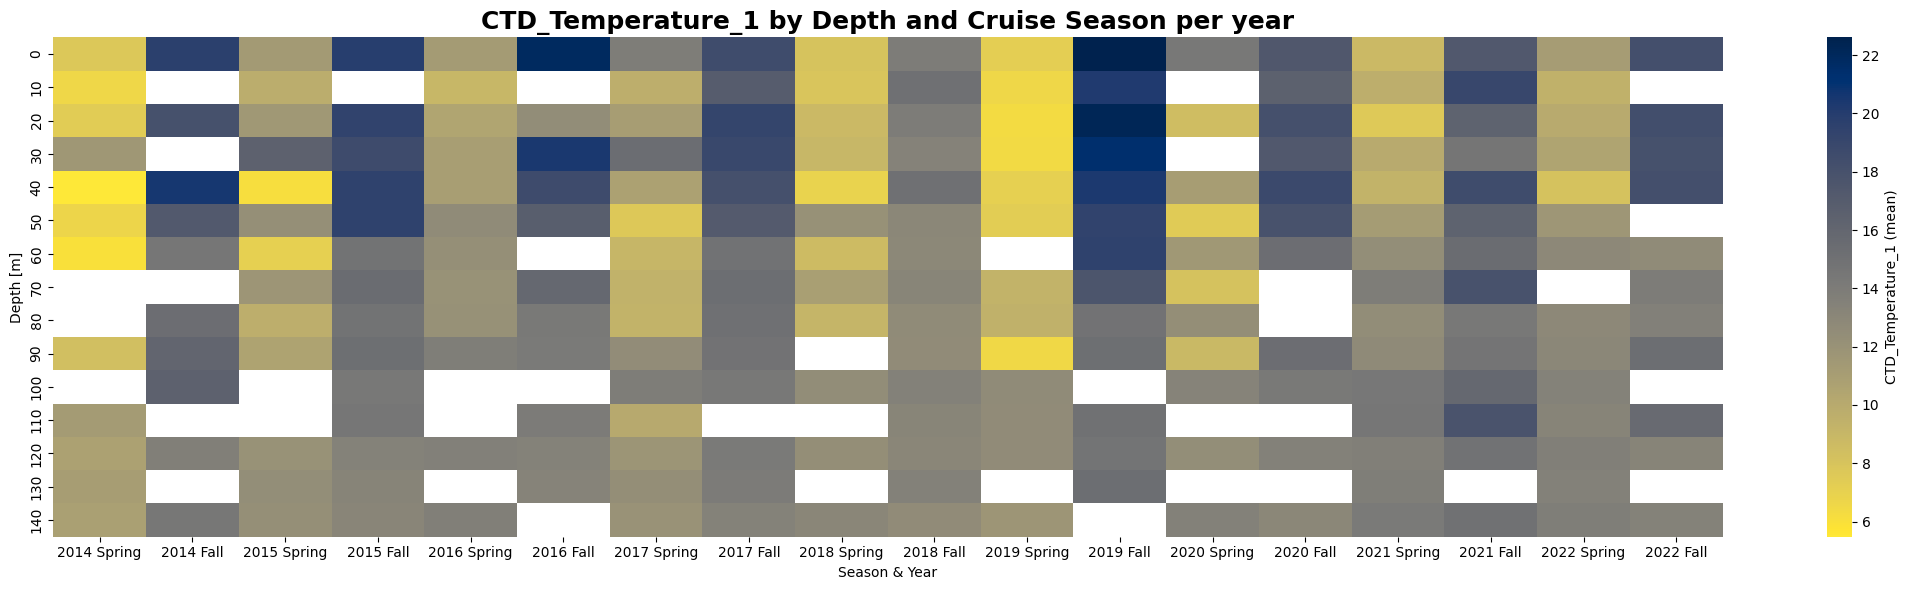

In [88]:
# Plot the plot
hovmoller_depth_cruise(df_qc, var="CTD_Temperature_1", season_labels=True)

**Figure 4.** (Above) Hovmöller diagram of seasonal mean sea water temperature in the upper 150 meters of the water column surrounding the array.